# A Multi-class classifier

In [1]:
import torch
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Generate data in blobs
RANDOM_SEED=42
NB_FEATURES=2
NB_BLOBS=4
X_set,y_set = make_blobs(n_samples=2000, n_features=NB_FEATURES, centers=NB_BLOBS, cluster_std=1.5, random_state=RANDOM_SEED)


tensor([[ 4.4471, -0.8496],
        [ 5.4521,  3.1119],
        [-8.9062, -8.8638],
        [-8.9192,  5.8501],
        [-5.8510,  6.0754]]) tensor([1, 1, 2, 3, 3])


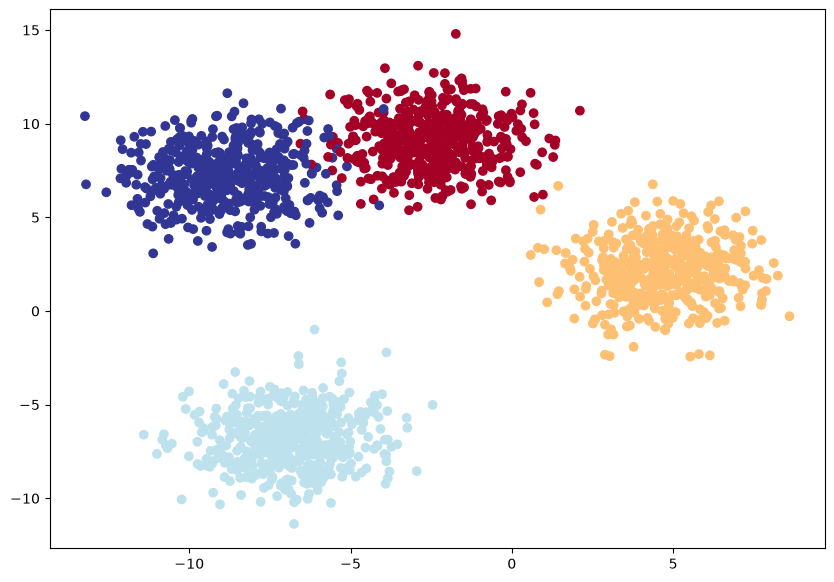

In [3]:
# transform as tensors
X = torch.from_numpy(X_set).type(torch.float)
y = torch.from_numpy(y_set).type(torch.LongTensor)
print(X[:5], y[:5])
# build train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

# Build the Neural Network


In [4]:
from torch import nn

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"

class BlobsClassifier(nn.Module):
    def __init__(self,input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features),
            #nn.ReLU()
        )       
        
    def forward(self,x):
        return self.linear_layer_stack(x)
model=BlobsClassifier(input_features=NB_FEATURES,output_features=NB_BLOBS).to(device)
model

BlobsClassifier(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [5]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates if two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [6]:
loss_fn=nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(params=model.parameters(), lr=0.1)

In [7]:
# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [8]:
# One forward inference
model(X_train)[:5]
# model is predicting one value for each class that we have.

tensor([[-1.1361,  1.4910,  0.3913,  0.8184],
        [ 0.3945,  0.6061,  0.5308,  0.1163],
        [-1.0647,  1.3469,  0.3784,  0.7982],
        [-1.1250,  1.5605,  0.3641,  0.6947],
        [-0.6938,  0.9586,  0.3733,  0.5164]], device='mps:0',
       grad_fn=<SliceBackward0>)

In [9]:
# To move to a class label, we need to map those 4 number per input to a probability to part of the matching class
# The softmax function calculates the probability of each prediction class being the actual predicted 
# class compared to all other possible classes.
y_logits = model(X_test)

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1) 
print(y_logits[:5])
print(y_pred_probs[:5])
# the sum for each element is close to 1
print(torch.sum(y_pred_probs[0]))
# These prediction probablities are essentially saying how much the model thinks the target X sample 
# (the input) maps to each class.

# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([[-0.4379,  1.1847,  0.5152,  0.3220],
        [ 0.5778, -0.8210,  0.3454,  0.5021],
        [-1.0818,  1.4539,  0.3618,  0.7080],
        [ 0.5467, -0.7897,  0.3803,  0.5070],
        [-0.8714,  0.9833,  0.3362,  0.7091]], device='mps:0',
       grad_fn=<SliceBackward0>)
tensor([[0.0926, 0.4692, 0.2402, 0.1980],
        [0.3371, 0.0832, 0.2672, 0.3125],
        [0.0419, 0.5294, 0.1776, 0.2511],
        [0.3257, 0.0856, 0.2757, 0.3130],
        [0.0641, 0.4098, 0.2146, 0.3115]], device='mps:0',
       grad_fn=<SliceBackward0>)
tensor(1.0000, device='mps:0', grad_fn=<SumBackward0>)
tensor([0.0926, 0.4692, 0.2402, 0.1980], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor(1, device='mps:0')


In [10]:
# Train the model and assess on test data
torch.manual_seed(RANDOM_SEED)
epochs=1000


for epoch in range(epochs):
    model.train()
    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    # from logits -> prediction probabilities -> prediction labels
    y_pred = torch.softmax(y_logits,dim=1).argmax(dim=1)
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Testing
    model.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model(X_test).squeeze() 
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 1.57294, Accuracy: 16.56% | Test loss: 1.15086, Test acc: 69.00
Epoch: 10 | Loss: 0.35746, Accuracy: 97.75% | Test loss: 0.30565, Test acc: 98.00
Epoch: 20 | Loss: 0.12074, Accuracy: 98.62% | Test loss: 0.11311, Test acc: 99.00
Epoch: 30 | Loss: 0.07594, Accuracy: 98.62% | Test loss: 0.07256, Test acc: 99.25
Epoch: 40 | Loss: 0.05990, Accuracy: 98.62% | Test loss: 0.05671, Test acc: 99.25
Epoch: 50 | Loss: 0.05186, Accuracy: 98.69% | Test loss: 0.04833, Test acc: 99.25
Epoch: 60 | Loss: 0.04708, Accuracy: 98.69% | Test loss: 0.04313, Test acc: 99.25
Epoch: 70 | Loss: 0.04397, Accuracy: 98.69% | Test loss: 0.03961, Test acc: 99.25
Epoch: 80 | Loss: 0.04182, Accuracy: 98.69% | Test loss: 0.03709, Test acc: 99.25
Epoch: 90 | Loss: 0.04024, Accuracy: 98.69% | Test loss: 0.03519, Test acc: 99.25


Epoch: 100 | Loss: 0.03904, Accuracy: 98.69% | Test loss: 0.03371, Test acc: 99.25
Epoch: 110 | Loss: 0.03810, Accuracy: 98.69% | Test loss: 0.03253, Test acc: 99.50
Epoch: 120 | Loss: 0.03735, Accuracy: 98.69% | Test loss: 0.03156, Test acc: 99.50
Epoch: 130 | Loss: 0.03673, Accuracy: 98.69% | Test loss: 0.03075, Test acc: 99.50
Epoch: 140 | Loss: 0.03621, Accuracy: 98.69% | Test loss: 0.03007, Test acc: 99.50
Epoch: 150 | Loss: 0.03577, Accuracy: 98.69% | Test loss: 0.02949, Test acc: 99.50


Epoch: 160 | Loss: 0.03539, Accuracy: 98.69% | Test loss: 0.02899, Test acc: 99.50
Epoch: 170 | Loss: 0.03507, Accuracy: 98.69% | Test loss: 0.02855, Test acc: 99.50
Epoch: 180 | Loss: 0.03478, Accuracy: 98.69% | Test loss: 0.02816, Test acc: 99.50
Epoch: 190 | Loss: 0.03453, Accuracy: 98.69% | Test loss: 0.02782, Test acc: 99.50
Epoch: 200 | Loss: 0.03430, Accuracy: 98.69% | Test loss: 0.02751, Test acc: 99.50
Epoch: 210 | Loss: 0.03410, Accuracy: 98.69% | Test loss: 0.02723, Test acc: 99.50
Epoch: 220 | Loss: 0.03391, Accuracy: 98.75% | Test loss: 0.02698, Test acc: 99.50
Epoch: 230 | Loss: 0.03374, Accuracy: 98.75% | Test loss: 0.02675, Test acc: 99.50
Epoch: 240 | Loss: 0.03359, Accuracy: 98.75% | Test loss: 0.02654, Test acc: 99.50
Epoch: 250 | Loss: 0.03344, Accuracy: 98.75% | Test loss: 0.02635, Test acc: 99.50
Epoch: 260 | Loss: 0.03331, Accuracy: 98.75% | Test loss: 0.02617, Test acc: 99.50


Epoch: 270 | Loss: 0.03318, Accuracy: 98.75% | Test loss: 0.02600, Test acc: 99.50
Epoch: 280 | Loss: 0.03307, Accuracy: 98.75% | Test loss: 0.02585, Test acc: 99.50
Epoch: 290 | Loss: 0.03296, Accuracy: 98.75% | Test loss: 0.02570, Test acc: 99.50
Epoch: 300 | Loss: 0.03285, Accuracy: 98.75% | Test loss: 0.02556, Test acc: 99.50
Epoch: 310 | Loss: 0.03275, Accuracy: 98.75% | Test loss: 0.02544, Test acc: 99.50
Epoch: 320 | Loss: 0.03266, Accuracy: 98.75% | Test loss: 0.02531, Test acc: 99.50


Epoch: 330 | Loss: 0.03257, Accuracy: 98.81% | Test loss: 0.02520, Test acc: 99.50
Epoch: 340 | Loss: 0.03249, Accuracy: 98.81% | Test loss: 0.02509, Test acc: 99.50
Epoch: 350 | Loss: 0.03240, Accuracy: 98.81% | Test loss: 0.02498, Test acc: 99.50
Epoch: 360 | Loss: 0.03233, Accuracy: 98.81% | Test loss: 0.02488, Test acc: 99.50
Epoch: 370 | Loss: 0.03225, Accuracy: 98.81% | Test loss: 0.02479, Test acc: 99.50
Epoch: 380 | Loss: 0.03218, Accuracy: 98.81% | Test loss: 0.02470, Test acc: 99.50
Epoch: 390 | Loss: 0.03211, Accuracy: 98.81% | Test loss: 0.02461, Test acc: 99.50
Epoch: 400 | Loss: 0.03204, Accuracy: 98.81% | Test loss: 0.02452, Test acc: 99.50
Epoch: 410 | Loss: 0.03198, Accuracy: 98.81% | Test loss: 0.02444, Test acc: 99.50
Epoch: 420 | Loss: 0.03191, Accuracy: 98.81% | Test loss: 0.02436, Test acc: 99.50
Epoch: 430 | Loss: 0.03185, Accuracy: 98.81% | Test loss: 0.02429, Test acc: 99.50


...

Epoch: 610 | Loss: 0.03097, Accuracy: 98.88% | Test loss: 0.02319, Test acc: 99.50
Epoch: 620 | Loss: 0.03093, Accuracy: 98.88% | Test loss: 0.02314, Test acc: 99.50
Epoch: 630 | Loss: 0.03089, Accuracy: 98.88% | Test loss: 0.02310, Test acc: 99.50
Epoch: 640 | Loss: 0.03085, Accuracy: 98.88% | Test loss: 0.02305, Test acc: 99.50
Epoch: 650 | Loss: 0.03081, Accuracy: 98.88% | Test loss: 0.02300, Test acc: 99.50
Epoch: 660 | Loss: 0.03077, Accuracy: 98.88% | Test loss: 0.02295, Test acc: 99.50


Epoch: 670 | Loss: 0.03074, Accuracy: 98.88% | Test loss: 0.02291, Test acc: 99.50
Epoch: 680 | Loss: 0.03070, Accuracy: 98.88% | Test loss: 0.02286, Test acc: 99.50
Epoch: 690 | Loss: 0.03066, Accuracy: 98.88% | Test loss: 0.02282, Test acc: 99.50
Epoch: 700 | Loss: 0.03063, Accuracy: 98.88% | Test loss: 0.02277, Test acc: 99.50
Epoch: 710 | Loss: 0.03059, Accuracy: 98.88% | Test loss: 0.02273, Test acc: 99.50
Epoch: 720 | Loss: 0.03056, Accuracy: 98.88% | Test loss: 0.02268, Test acc: 99.50
Epoch: 730 | Loss: 0.03052, Accuracy: 98.88% | Test loss: 0.02264, Test acc: 99.50
Epoch: 740 | Loss: 0.03049, Accuracy: 98.88% | Test loss: 0.02260, Test acc: 99.50
Epoch: 750 | Loss: 0.03045, Accuracy: 98.88% | Test loss: 0.02256, Test acc: 99.50
Epoch: 760 | Loss: 0.03042, Accuracy: 98.88% | Test loss: 0.02251, Test acc: 99.50
Epoch: 770 | Loss: 0.03039, Accuracy: 98.94% | Test loss: 0.02247, Test acc: 99.50


Epoch: 780 | Loss: 0.03035, Accuracy: 98.94% | Test loss: 0.02243, Test acc: 99.50
Epoch: 790 | Loss: 0.03032, Accuracy: 98.94% | Test loss: 0.02239, Test acc: 99.50
Epoch: 800 | Loss: 0.03029, Accuracy: 98.94% | Test loss: 0.02235, Test acc: 99.50
Epoch: 810 | Loss: 0.03026, Accuracy: 98.94% | Test loss: 0.02231, Test acc: 99.50
Epoch: 820 | Loss: 0.03022, Accuracy: 98.94% | Test loss: 0.02227, Test acc: 99.50
Epoch: 830 | Loss: 0.03019, Accuracy: 98.94% | Test loss: 0.02223, Test acc: 99.50


Epoch: 840 | Loss: 0.03016, Accuracy: 98.94% | Test loss: 0.02219, Test acc: 99.50
Epoch: 850 | Loss: 0.03013, Accuracy: 98.94% | Test loss: 0.02216, Test acc: 99.50
Epoch: 860 | Loss: 0.03010, Accuracy: 98.94% | Test loss: 0.02212, Test acc: 99.50
Epoch: 870 | Loss: 0.03007, Accuracy: 98.94% | Test loss: 0.02208, Test acc: 99.50
Epoch: 880 | Loss: 0.03004, Accuracy: 98.94% | Test loss: 0.02204, Test acc: 99.50
Epoch: 890 | Loss: 0.03001, Accuracy: 98.94% | Test loss: 0.02201, Test acc: 99.50
Epoch: 900 | Loss: 0.02998, Accuracy: 98.94% | Test loss: 0.02197, Test acc: 99.50
Epoch: 910 | Loss: 0.02995, Accuracy: 98.94% | Test loss: 0.02193, Test acc: 99.50
Epoch: 920 | Loss: 0.02992, Accuracy: 98.94% | Test loss: 0.02190, Test acc: 99.50
Epoch: 930 | Loss: 0.02990, Accuracy: 98.94% | Test loss: 0.02186, Test acc: 99.50
Epoch: 940 | Loss: 0.02987, Accuracy: 98.94% | Test loss: 0.02183, Test acc: 99.50


Epoch: 950 | Loss: 0.02984, Accuracy: 98.94% | Test loss: 0.02179, Test acc: 99.50
Epoch: 960 | Loss: 0.02981, Accuracy: 98.94% | Test loss: 0.02176, Test acc: 99.50
Epoch: 970 | Loss: 0.02978, Accuracy: 98.94% | Test loss: 0.02172, Test acc: 99.50
Epoch: 980 | Loss: 0.02976, Accuracy: 98.94% | Test loss: 0.02169, Test acc: 99.50
Epoch: 990 | Loss: 0.02973, Accuracy: 98.94% | Test loss: 0.02165, Test acc: 99.50


In [11]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
print(f"Predictions: {y_preds[:10]}\nLabels: {y_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_test, y_pred=y_preds)}%")

Predictions: tensor([0, 2, 3, 2, 3, 3, 1, 1, 3, 0], device='mps:0')
Labels: tensor([0, 2, 3, 2, 3, 3, 1, 1, 3, 0], device='mps:0')
Test accuracy: 99.5%


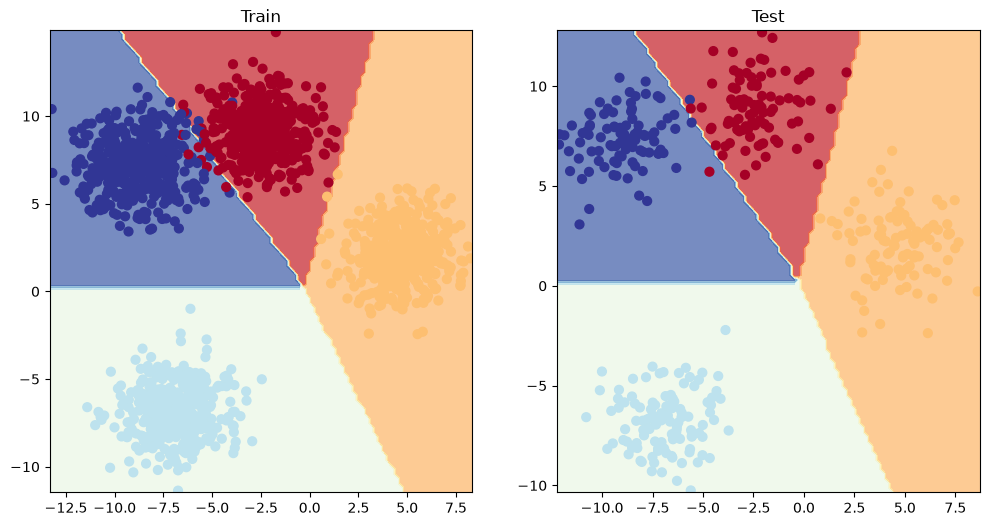

In [12]:
from helper_functions import plot_predictions, plot_decision_boundary
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)